# Model YOLO with no prompt

## Chargement des libraries

In [1]:
import cv2
import os
import yaml
import random
import sys
import gc
import pandas as pd
import numpy as np
import torch
import pickle

# CUDA déterministe
os.environ.setdefault("PYTHONHASHSEED", "42")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

from pathlib import Path
from ultralytics import YOLO
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

from utils.models_config import metrics_by_class
from utils.yolo_metrics import (
    load_yolo_polygon_masks,
    metrics_from_counts,
    result_to_masks,
)
from utils.stats_fct import plot_segmentation_comparison

/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reproductibilité du code

In [2]:
# Seed global pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)
torch.set_float32_matmul_precision("highest")

# Déterminisme complet des opérations cuDNN (au prix d'un léger ralentissement)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.is_available()

True

### Choix des données

In [12]:
DATASET_NAME = "oeufs"  # "3classes" ou "2classses" ou "oeufs"

### Choix du type de modèle

In [13]:
MODEL_TYPE = "instance"  # "semantique" ou "instance"

### Echantillonnage stratifié train/val - test

In [42]:
# ------- 1. Importation du Data Frame avec les metadata --------
metadata = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# -------- 2. Chemin des images --------
DATASET_CONFIG = {
    "3classes": {"images": "../data/YOLO/images", "classes" : ["Cavite", "Gonade", "Intestin"]},
    "oeufs": {"images": "../data/YOLO/oeufs/images", "classes" : ["Oeuf"]},
}
images_path = Path(DATASET_CONFIG[DATASET_NAME]["images"])
# L'ordre de os.listdir peut varier : il doit être figé avant tout split.
image_files = sorted(os.listdir(images_path))

# -------- 3. Extraire les catégories pour chaque image --------
categories_all = []
for path in image_files:
    id_image = path.split("_")[0]
    
    matches = metadata.loc[metadata["image_id"] == id_image, "categorie"]

    if not matches.empty:
        # On prend la première valeur trouvée si des doublons existent
        cat = matches.values[0]
        categories_all.append(cat)
    else:
        # Si l'id_image n'existe pas du tout dans le fichier
        print(f"Image {id_image} introuvable dans les métadonnées.")
        categories_all.append(None)

# ----- 4. Séparation stratifiée par groupe : 85% Train/val et 15% Test -----
X = np.array(image_files, dtype=object) # Les images
groups = np.array([path.split("_")[2] for path in image_files]) # L'ID du poisson pour chaque image
k_folds = 6

def get_cv_splits():
    if DATASET_NAME == "oeufs":
        kf = GroupKFold(n_splits=k_folds, shuffle=True, random_state=42) # Les œufs n'ont pas de catégories d'échographie : on groupe uniquement par poisson.
        return kf.split(X, groups=groups)
    
    return kf.split(X, y, groups=groups)

kf = StratifiedGroupKFold(n_splits=k_folds, random_state=42, shuffle=True)
# On utilise 6 splits pour simuler un ratio 83/17 (proche de 85/15)
if DATASET_NAME == "oeufs":
    for cv_idx, test_idx in get_cv_splits():
        cv_paths, test_paths = X[cv_idx], X[test_idx]
        groups_train, groups_test = groups[cv_idx], groups[test_idx]
        break # On ne garde que le premier split
else:
    y = np.array(categories_all) # Les classes
    for cv_idx, test_idx in get_cv_splits():
        cv_paths, test_paths = X[cv_idx], X[test_idx]
        cv_categories, test_categories = y[cv_idx], y[test_idx]
        groups_train, groups_test = groups[cv_idx], groups[test_idx]
        break # On ne garde que le premier split
    y = cv_categories


print(f"Nombre total d'images valides : {len(image_files)}")
print(f"Échantillons train/val        : {len(cv_paths)}")
print(f"Échantillons de test          : {len(test_paths)}")

# Récupère le chemin en entier
X = [str(images_path / path) for path in cv_paths]
groups = groups_train

Nombre total d'images valides : 69
Échantillons train/val        : 58
Échantillons de test          : 11


In [43]:
test_paths

array(['0004859_14.21.57_362702_2020.jpg', '0004880_15.30.04_362793_2020.jpg', '0005926_11.36.05_405826_2022.jpg', '0005957_13.57.27_405924_2022.jpg', '0006147_14.56.42_406377_2022.jpg', '0006148_14.57.15_406377_2022.jpg', '0006149_14.57.29_406377_2022.jpg', '0006218_10.45.49_406703_2022.jpg',
       '0006943_10.28.10_426735_2024.jpg', '0007130_10.24.52_427237_2024.jpg', '0007146_10.59.47_427276_2024.jpg'], dtype=object)

### Hyperparamètres

In [44]:
# ------- 1. Paramètres du yaml --------
nc = len(DATASET_CONFIG[DATASET_NAME]["classes"])
names = DATASET_CONFIG[DATASET_NAME]["classes"]
names_mapping = {i: name for i, name in enumerate(names)}
label_mapping = {i: i for i in range(nc)}
if DATASET_NAME == "3classes":
    label_mapping[3] = "ignore_label"

# ------ 2. Découpage k-folds pour la cross validation --------
k_folds = 5

# ------ 3. Initialisation --------
results_list = []
val_paths_list = []

IMAGE_SIZE = 512
TRAIN_DEVICE = 0 if torch.cuda.is_available() else "cpu"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Entrainement et validation du modèle

In [45]:
for fold, (train_index, val_index) in enumerate(get_cv_splits()):
    print(f"\n{'='*30}\nLancement du Fold {fold + 1}/{k_folds}\n{'='*30}")

    cv_images = X
    # Séparer les chemins
    train_paths = [cv_images[i] for i in train_index]
    val_paths = [cv_images[i] for i in val_index]
    
    # Créer les fichiers .txt contenant les chemins
    train_txt = f'folds/train_fold_{fold}.txt'
    val_txt = f'folds/val_fold_{fold}.txt'

    with open(train_txt, 'w') as f:
        f.write('\n'.join(train_paths))
    with open(val_txt, 'w') as f:
        f.write('\n'.join(val_paths))
        
    # Créer le fichier .yaml
    yaml_data = {
        'train': train_txt,
        'val': val_txt,
        'nc': nc,
        'names': names_mapping,
        'label_mapping': label_mapping
    }

    yaml_file = f'data_fold_{fold}.yaml'
    with open(yaml_file, 'w') as f:
        yaml.dump(yaml_data, f, default_flow_style=False)
        
    # -------- Entrainement du modèle --------
    # Initialisation
    if MODEL_TYPE == "instance":
        model = YOLO("yolo26l-seg.pt")
    elif MODEL_TYPE == "semantique":
        model = YOLO("yolo26l-sem.pt")
    
    # Entraînement
    model.train(data=yaml_file, epochs=100, patience = 10, lr0 = 0.0001,
            hsv_h=0.0,
            hsv_s=0.0,
            hsv_v=0.4, #0.4
            degrees=20, #20
            translate=0.2, #0.2
            scale=0.2, #0.2
            fliplr=0.0,
            mosaic=0.0,
            erasing=0.0,
            auto_augment=None,
            box=15.0,
            cls=0.3,
            imgsz=IMAGE_SIZE,
            name = "train_" + DATASET_NAME + "_" + MODEL_TYPE + "_fold_" + str(fold + 1), # Rennomage des résultats
            exist_ok = True, # Ecrase le fichier si il existe déjà
            seed=SEED,
            deterministic=True,
            workers=0,
            amp=False,
            device=TRAIN_DEVICE
            ) 
    
    # -------- Validation et prédiction du modèle --------
    print(f"\nÉvaluation du Fold {fold + 1}...")
    results = model.val(data=yaml_file, 
                        name = "val_" + DATASET_NAME + "_" + MODEL_TYPE + "_fold_" + str(fold + 1),
                        exist_ok = True,
                        seed=SEED,
                        deterministic=True,
                        workers=0,
                        amp=False,
                        device=TRAIN_DEVICE
                        )
    preds = model.predict(source=val_paths, retina_masks=True, conf=0.2, verbose=False,
                          seed=SEED, workers=0, device=TRAIN_DEVICE, amp=False)
    
    results_list.append(preds)    
    val_paths_list.append(val_paths)

    # ---------------------------------------------------------
    # Nettoyage de la mémoire GPU pour éviter l'erreur NVML
    # ---------------------------------------------------------
    del model
    del results
    del preds
    gc.collect()
    torch.cuda.empty_cache()

print("\nValidation croisée terminée avec succès !")


Lancement du Fold 1/5
New https://pypi.org/project/ultralytics/8.4.123 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.70 🚀 Python-3.14.4 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX A5000, 24114MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=15.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.3, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_fold_0.yaml, degrees=20, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l-seg.pt, momentum=0.937, mosaic=0.0, multi_scal

### Calcul des métriques

In [46]:
# ------ Historique détaillé des métriques de validation ------
fold_history = {}

for fold_index, (fold_paths, fold_predictions) in enumerate(zip(val_paths_list, results_list), start=1):
    fold_history[fold_index] = []
    if len(fold_paths) != len(fold_predictions):
        raise ValueError(f"Le fold {fold_index} contient {len(fold_paths)} chemins mais {len(fold_predictions)} prédictions.")

    for image_path, prediction in zip(fold_paths, fold_predictions):
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Image de validation introuvable : {image_path}")
        image_height, image_width = image.shape[:2]
        label_path = image_path.replace('/images/', '/labels/').replace('.jpg', '.txt')
        true_mask_np = load_yolo_polygon_masks(label_path, (image_height, image_width), nc, semantic=MODEL_TYPE == "semantique")
        pred_mask_np = result_to_masks(prediction, names, nc, semantic=MODEL_TYPE == "semantique")
        true_batch = torch.from_numpy(true_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)
        pred_batch = torch.from_numpy(pred_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)

        if DATASET_NAME == "oeufs":
            image_scale = 1.0
        else:
            image_name = os.path.basename(image_path)
            scale_rows = metadata.loc[metadata["image_id"] == image_name.split("_")[0], "echelle"]
            if scale_rows.empty:
                raise ValueError(f"Échelle introuvable pour {image_name}")
            image_scale = float(scale_rows.iloc[0])

        image_intersection, image_union, image_iou, image_dice, image_precision, image_recall, image_diff_surface = metrics_by_class(
            true=true_batch, preds=pred_batch,
            echelle=torch.tensor([[image_scale]], device=device, dtype=torch.float32),
            dataset_name=DATASET_NAME,
        )
        true_area = true_batch.sum(dim=(2, 3)).float()
        pred_area = pred_batch.sum(dim=(2, 3)).float()
        empty = (true_area + pred_area) == 0
        for metric in (image_iou, image_dice, image_precision, image_recall):
            metric[empty] = 1.0

        image_metrics = {}
        for class_index, class_name in enumerate(names):
            image_metrics[class_name] = {
                "dice": float(image_dice[0, class_index].item()),
                "iou": float(image_iou[0, class_index].item()),
                "precision": float(image_precision[0, class_index].item()),
                "recall": float(image_recall[0, class_index].item()),
                "diff_surface": float(image_diff_surface[0, class_index].item()),
            }

        global_intersection = image_intersection.sum()
        global_union = image_union.sum()
        global_true_area = true_area.sum()
        global_pred_area = pred_area.sum()
        image_metrics["Global"] = {
            "dice": float((2 * global_intersection / (global_true_area + global_pred_area)).item()) if global_true_area + global_pred_area > 0 else 1.0,
            "iou": float((global_intersection / global_union).item()) if global_union > 0 else 1.0,
            "precision": float((global_intersection / global_pred_area).item()) if global_pred_area > 0 else float(global_true_area == 0),
            "recall": float((global_intersection / global_true_area).item()) if global_true_area > 0 else float(global_pred_area == 0),
            "diff_surface": float(image_diff_surface.sum().item()),
        }

        fold_history[fold_index].append({
            "image": os.path.basename(image_path),
            "path": str(image_path),
            "metrics": image_metrics,
        })

print({fold: len(images) for fold, images in fold_history.items()})


{1: 16, 2: 12, 3: 9, 4: 9, 5: 12}


### Sauvegarde des métriques

In [47]:
with open(f'saves/results_YOLO_{MODEL_TYPE}_{DATASET_NAME}.pkl', 'wb') as fp:
    pickle.dump(fold_history, fp)

## Résultats validation

### Choix de l'image

In [67]:
# ----- 1. Choix du fold et de l'image à visualiser -----
VIS_FOLD = 5  # Numéro du fold, entre 1 et k_folds
VIS_INDEX = 9  # Index de l'image dans le jeu de validation du fold (0 à len(val_paths)-1)

# ----- 2. Reconstruction du fold de validation ----
if not 1 <= VIS_FOLD <= k_folds:
    raise ValueError(f"VIS_FOLD doit être compris entre 1 et {k_folds}.")

_, val_indices = list(get_cv_splits())[VIS_FOLD - 1]
val_indices = np.asarray(val_indices)
val_paths = [X[i] for i in val_indices]
print(f"Nombre de folds disponibles : {k_folds}")
print(f"Nombre d'images dans le fold {VIS_FOLD}: {len(val_paths)}")

if not 0 <= VIS_INDEX < len(val_paths):
    raise IndexError(
        f"VIS_INDEX doit être compris entre 0 et {len(val_paths) - 1} "
        f"pour le fold {VIS_FOLD}."
    )

checkpoint_path = Path(
    f"runs/segment/train_{DATASET_NAME}_{MODEL_TYPE}_fold_{VIS_FOLD}/weights/best.pt"
)
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")

Nombre de folds disponibles : 5
Nombre d'images dans le fold 5: 12


### Visualisation des résultats

Image : 0005116_14.43.22_363778_2020.jpg


,dice,iou,precision,recall,diff_surface (pixels)
classe,,,,,
Oeuf,0.5096,0.3419,0.5087,0.5105,23.0000
Global,0.5096,0.3419,0.5087,0.5105,23.0000


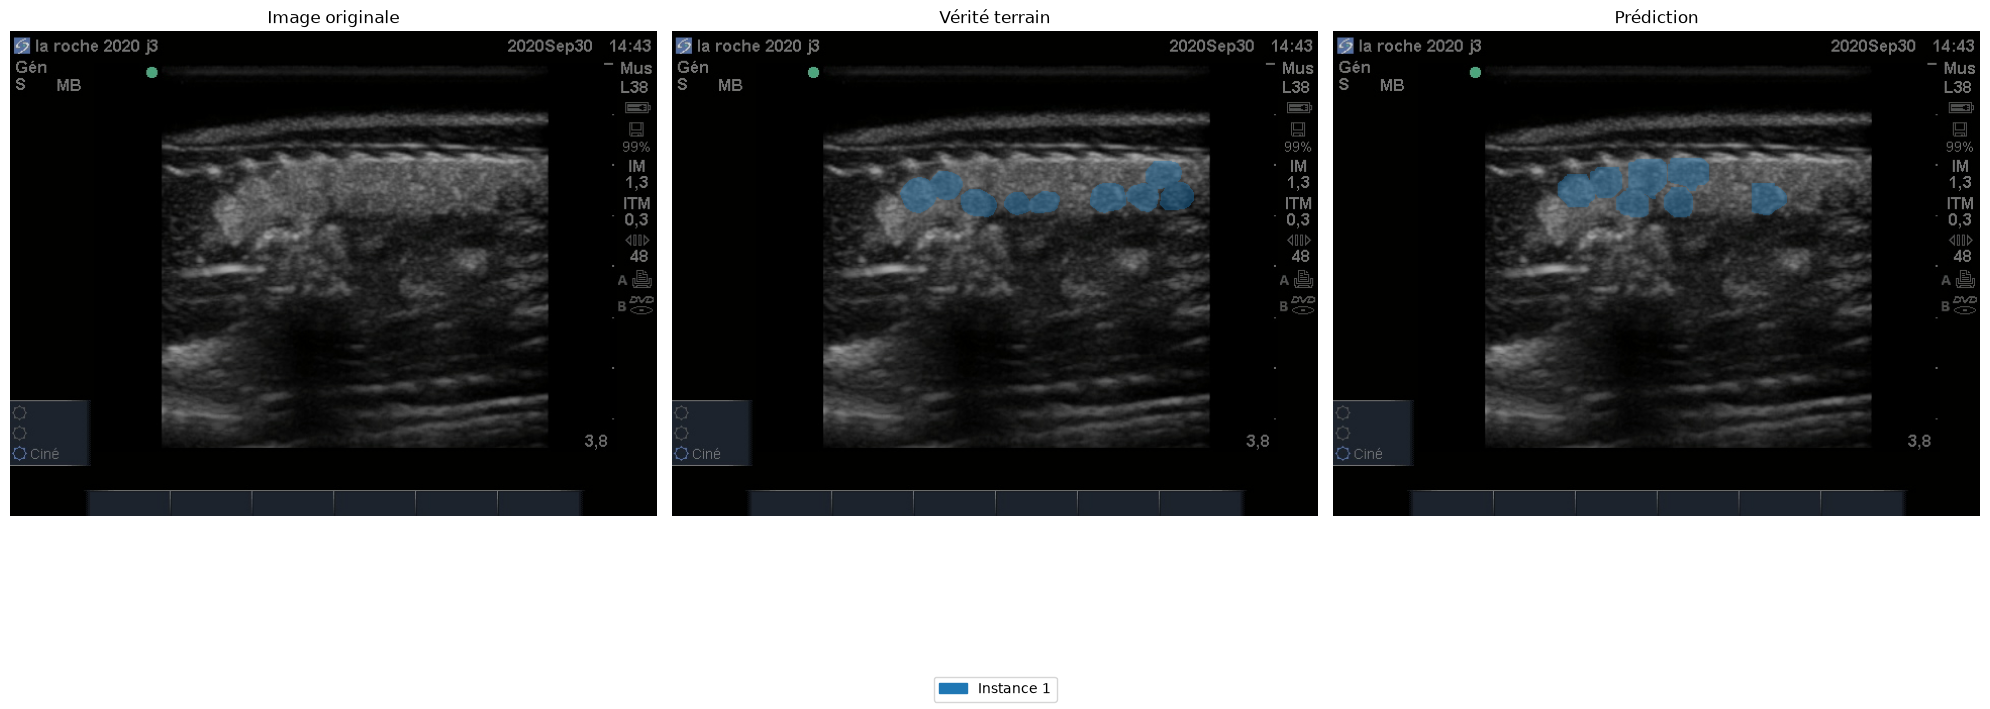

(<Figure size 2000x800 with 3 Axes>,
 array([<Axes: title={'center': 'Image originale'}>, <Axes: title={'center': 'Vérité terrain'}>, <Axes: title={'center': 'Prédiction'}>], dtype=object))

In [68]:
# Affichage des figures dans le notebook
%matplotlib inline

# Chemin du masque correspondant à l'image
val_path = val_paths[VIS_INDEX]
mask_path = val_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

# ----- 1. Chargement de l'image -----
img_bgr = cv2.imread(val_path)
H_orig, W_orig, _ = img_bgr.shape

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Conversion de l'image en tenseur
image_tensor = torch.tensor(img_rgb).permute(2, 0, 1).float() / 255.0
_, H, W = image_tensor.shape

# ----- 3. Chargement du checkpoint et prédiction -----
model_eval = YOLO(str(checkpoint_path))
predictions = model_eval.predict(
    source=val_path, retina_masks=True, conf=0.2, verbose=False,
    seed=SEED, workers=0, device=TRAIN_DEVICE, amp=False,
)
preds = predictions[0]

# Conversion de la sortie YOLO en canaux dans l'ordre des classes du dataset
if MODEL_TYPE == "semantique":
    p_mask = result_to_masks(preds, names, nc, semantic=True)

# Si segmentation d'instances
elif MODEL_TYPE == "instance":
    # On initialise un masque vide aux dimensions exactes de l'image originale
    p_mask = np.zeros((nc, H_orig, W_orig), dtype=np.uint8)

    if hasattr(preds, 'masks') and preds.masks is not None:
        # On parcourt chaque instance détectée
        p_mask = result_to_masks(preds, names, nc, semantic=False)

# ----- 4. Récupération du masque réel -----
# En sémantique, les polygones internes écrasent la cavité comme pendant l'entraînement.
if not os.path.exists(mask_path):
    print(f"Attention : Aucun label trouvé à {mask_path}, un masque vide sera utilisé.")
t_mask_np = load_yolo_polygon_masks(
    mask_path,
    (H_orig, W_orig),
    nc,
    semantic=MODEL_TYPE == "semantique",
)


# ----- 5. Formatage des tenseurs -----
# metrics_by_class attend des tenseurs booléens de forme [B, C, H, W] : ajoute une dimension "Batch" (B=1) avec unsqueeze(0)
true_tensor = torch.from_numpy(t_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)
preds_tensor = torch.from_numpy(p_mask).unsqueeze(0).to(device=device) > 0.5 

# ----- 6. Récupération de l'échelle ------
if DATASET_NAME == "oeufs":
    scale = 1.0
else:
    file_name = os.path.basename(val_path)
    scale_rows = metadata.loc[metadata["image_id"] == file_name.split("_")[0], "echelle"]
    if scale_rows.empty:
        raise ValueError(f"Échelle introuvable pour {file_name}")
    scale = float(scale_rows.iloc[0])

scale_tensor = torch.tensor([[scale]], device=device, dtype=torch.float32)

# ------ 7. Calcul des métriques -------
intersection, union, iou, dice, precision, recall, diff_surface = metrics_by_class(
    true=true_tensor, 
    preds=preds_tensor, 
    echelle=scale_tensor, 
    dataset_name=DATASET_NAME
)

# Correction du cas où le masque prédit et le masque réel sont vides
true_area = true_tensor.sum(dim=(2, 3)).float()
pred_area = preds_tensor.sum(dim=(2, 3)).float()
empty = (true_area + pred_area) == 0
for metric in (iou, dice, precision, recall):
    metric[empty] = 1.0

# ----- 8. Affichage des métriques -----
print(f"Image : {os.path.basename(val_path)}")

metric_rows = []
for class_idx, class_name in enumerate(names):
    metric_rows.append({
        "classe": class_name,
        "dice": dice[0, class_idx].item(),
        "iou": iou[0, class_idx].item(),
        "precision": precision[0, class_idx].item(),
        "recall": recall[0, class_idx].item(),
        "diff_surface": diff_surface[0, class_idx].item(),
    })

intersection_global = intersection.sum()
union_global = union.sum()
true_global = true_area.sum()
pred_global = pred_area.sum()
metric_rows.append({
    "classe": "Global",
    "dice": (2 * intersection_global / (true_global + pred_global)).item() if true_global + pred_global > 0 else 1.0,
    "iou": (intersection_global / union_global).item() if union_global > 0 else 1.0,
    "precision": (intersection_global / pred_global).item() if pred_global > 0 else float(true_global == 0),
    "recall": (intersection_global / true_global).item() if true_global > 0 else float(pred_global == 0),
    "diff_surface": diff_surface.sum().item(),
})

metrics_table = pd.DataFrame(metric_rows).set_index('classe')
surface_unit = "pixels" if DATASET_NAME == "oeufs" else "cm²"
metrics_table = metrics_table.rename(columns={"diff_surface": f"diff_surface ({surface_unit})"})
display(metrics_table.style.format(precision=4))

# ------ 9. Affichage de l'image, du masque vrai et de la prédiction -------
plot_segmentation_comparison(
    image= image_tensor,
    mask_true = torch.tensor(t_mask_np),
    mask_pred=torch.tensor(p_mask),
    is_eggs=DATASET_NAME == "oeufs",
    alpha=0.45
)